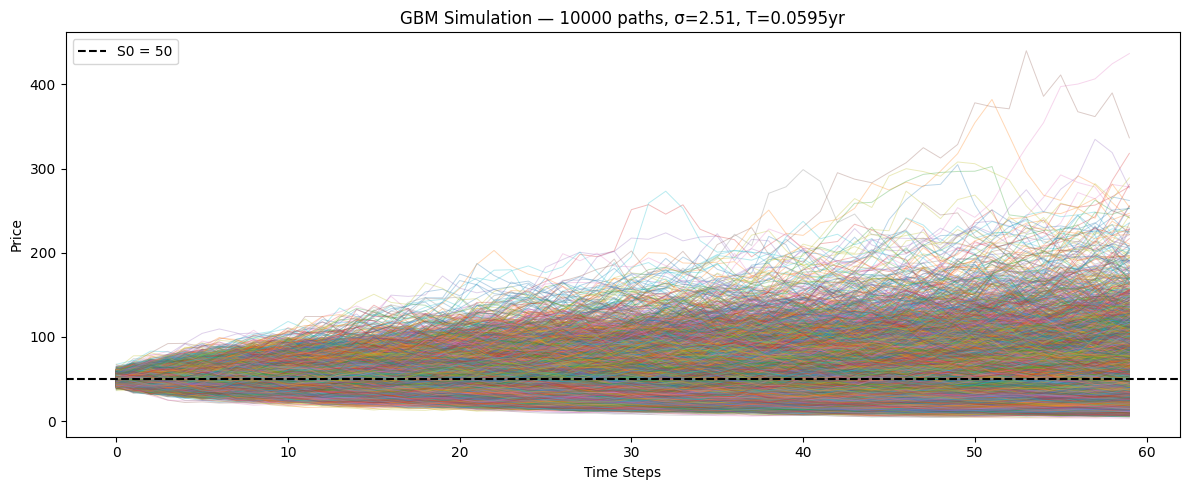

Mean final price:   49.6128
Median final price: 40.9108
Std of final price: 33.2894
Min: 3.3233  Max: 436.5466


In [2]:
import numpy as np
from matplotlib import pyplot as plt

def simulate_gbm(S0, sigma, T, N, i):
    # Time increment per step
    dt = T / N 
    
    # Time array: [dt, 2dt, ..., T] — shape (N,)
    t = np.linspace(dt, T, N)
    
    # Random shocks: shape (i, N)
    Z = np.random.standard_normal((i, N))
    
    # Brownian motion paths via cumulative sum — shape (i, N)
    W = np.cumsum(Z * np.sqrt(dt), axis=1)
    
    # GBM formula — t broadcasts across i paths
    # -0.5*sigma^2*t is the Ito correction (zero drift)
    all_paths = S0 * np.exp(-0.5 * sigma**2 * t + sigma * W)
    
    return all_paths  # shape (i, N)

S0 = 50         # initial price
sigma = 2.51    # annualized volatility (251%)
T = 15/252      # 15 trading days total
N = 15 * 4      # 60 steps total
i = 10000         # number of paths to simulate

paths = simulate_gbm(S0, sigma, T, N, i)

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.plot(paths.T, alpha=0.3, linewidth=0.7)
plt.axhline(S0, color='black', linewidth=1.5, linestyle='--', label=f'S0 = {S0}')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.title(f'GBM Simulation — {i} paths, σ={sigma}, T={T:.4f}yr')
plt.legend()
plt.tight_layout()
plt.show()

# --- Summary stats ---
final_prices = paths[:, -1]
print(f"Mean final price:   {final_prices.mean():.4f}")
print(f"Median final price: {np.median(final_prices):.4f}")
print(f"Std of final price: {final_prices.std():.4f}")
print(f"Min: {final_prices.min():.4f}  Max: {final_prices.max():.4f}")

In [3]:
## Black Scholes formula for regular options
from scipy.stats import norm

def bs_price(S0, K, T, sigma, option_type='call'):
    d1 = (np.log(S0 / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        return S0 * norm.cdf(d1) - K * norm.cdf(d2)
    else:  # put
        return K * norm.cdf(-d2) - S0 * norm.cdf(-d1)

## PARAMS
S0 = 50         # initial price
sigma = 2.51    # annualized volatility (251%)
T = 15/252      # 15 trading days total
T_alt = 10/252  # 10 trading days total

## 50 PUT (3 week)
K = 50
print(f"50 PUT (3 week): {bs_price(S0, K, T, sigma, 'put'):.4f}")

## 50 CALL (3 week)
K = 50
print(f"50 CALL (3 week): {bs_price(S0, K, T, sigma, 'call'):.4f}")

## 35 PUT (3 week)
K = 35
print(f"35 PUT (3 week): {bs_price(S0, K, T, sigma, 'put'):.4f}")

## 40 PUT (3 week)
K = 40
print(f"40 PUT (3 week): {bs_price(S0, K, T, sigma, 'put'):.4f}")

## 45 PUT (3 week)
K = 45
print(f"45 PUT (3 week): {bs_price(S0, K, T, sigma, 'put'):.4f}")

## 60 CALL (3 week)
K = 60
print(f"60 CALL (3 week): {bs_price(S0, K, T, sigma, 'call'):.4f}")

## 50 PUT (2 week)
K = 50
print(f"50 PUT (2 week): {bs_price(S0, K, T_alt, sigma, 'put'):.4f}")

## 50 CALL (2 week)
K = 50
print(f"50 CALL (2 week): {bs_price(S0, K, T_alt, sigma, 'call'):.4f}")





50 PUT (3 week): 12.0269
50 CALL (3 week): 12.0269
35 PUT (3 week): 4.3361
40 PUT (3 week): 6.5095
45 PUT (3 week): 9.0889
60 CALL (3 week): 8.7918
50 PUT (2 week): 9.8707
50 CALL (2 week): 9.8707


In [4]:
## Binary Put

def bs_binary_put(S0, K, T, sigma, Q):
    """
    S0: current price
    K:  strike
    T:  TTE in years (trading days / 252)
    sigma: annualised vol
    Q:  fixed payout amount
    """
    d2 = (np.log(S0 / K) - 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return Q * norm.cdf(-d2)

## 40 BINARY PUT {10 fixed} (3 week)
S0 = 50         # initial price
sigma = 2.51    # annualized volatility (251%)
T = 15/252      # 15 trading days total
Q = 10          # fixed payout
K = 40
print(f"40 BINARY PUT (3 week): {bs_binary_put(S0, K, T, sigma, Q):.4f}")

40 BINARY PUT (3 week): 4.7679


In [ ]:
## Simulate Options


S0 = 50         # initial price
sigma = 2.51    # annualized volatility (251%)
T = 15/252      # 15 trading days total
N = 15 * 4      # 60 steps total
i = 1_000_000         # number of paths to simulate

paths = simulate_gbm(S0, sigma, T, N, i)
three_week_prices = paths[:, 59]
two_week_prices = paths[:, 39]

fifty_put_three = 0
fifty_call_three = 0
thirtyfive_put_three = 0
forty_put_three = 0
fourtyfive_put_three = 0
sixty_call_three = 0
fifty_put_two = 0
fifty_call_two = 0
fourty_binary_put_three = 0

for item in three_week_prices:
    fifty_put_three += max(50 - item, 0) / i
    fifty_call_three += max(item - 50, 0) / i
    thirtyfive_put_three += max(35 - item, 0) / i
    forty_put_three += max(40 - item, 0) / i
    fourtyfive_put_three += max(45 - item, 0) / i
    sixty_call_three += max(item - 60, 0) / i
    fourty_binary_put_three += 10 / i if item < 40 else 0

for item in two_week_prices:
    fifty_put_two += max(50 - item, 0) / i
    fifty_call_two += max(item - 50, 0) / i

print(f"50 PUT (3 week): {fifty_put_three:.4f}")
print(f"50 CALL (3 week): {fifty_call_three:.4f}")
print(f"35 PUT (3 week): {thirtyfive_put_three:.4f}")
print(f"40 PUT (3 week): {forty_put_three:.4f}")
print(f"45 PUT (3 week): {fourtyfive_put_three:.4f}")
print(f"60 CALL (3 week): {sixty_call_three:.4f}")
print(f"50 PUT (2 week): {fifty_put_two:.4f}")
print(f"50 CALL (2 week): {fifty_call_two:.4f}")

## Special Options - CHOOSER
fifty_chooser_two_three = 0
choices = np.array([1 if item > 50 else -1 for item in two_week_prices])

for num, item in enumerate(three_week_prices):
    if choices[num] == 1:
        fifty_chooser_two_three += max(item - 50, 0) / i
    else:
        fifty_chooser_two_three += max(50 - item, 0) / i

print(f"50 CHOOSER (2 or 3 week): {fifty_chooser_two_three:.4f}")

## Special Options - BINARY PUT
print(f"40 BINARY PUT (3 week): {fourty_binary_put_three:.4f}")

## Special Options - KNOCKOUT PUT
row_mins = paths.min(axis=1)
fourtyfive_knockout_put = 0
selected = np.array([1 if item >= 35 else -1 for item in row_mins])
for num, item in enumerate(three_week_prices):
    if selected[num] == 1:
        fourtyfive_knockout_put += max(45 - item, 0) / i
    else:
        fourtyfive_knockout_put += 0

print(f"45 KNOCKOUT PUT (3 week): {fourtyfive_knockout_put:.4f}")



50 PUT (3 week): 12.0160
50 CALL (3 week): 12.0829
35 PUT (3 week): 4.3377
40 PUT (3 week): 6.5059
45 PUT (3 week): 9.0805
60 CALL (3 week): 8.8417
50 PUT (2 week): 9.8693
50 CALL (2 week): 9.9020
50 CHOOSER (2 or 3 week): 21.9358
40 BINARY PUT (3 week): 4.7547
45 KNOCKOUT PUT (3 week): 0.2064


Completed 0 simulations...
Completed 10000 simulations...
Completed 20000 simulations...
Completed 30000 simulations...
Completed 40000 simulations...
Completed 50000 simulations...
Completed 60000 simulations...
Completed 70000 simulations...
Completed 80000 simulations...
Completed 90000 simulations...


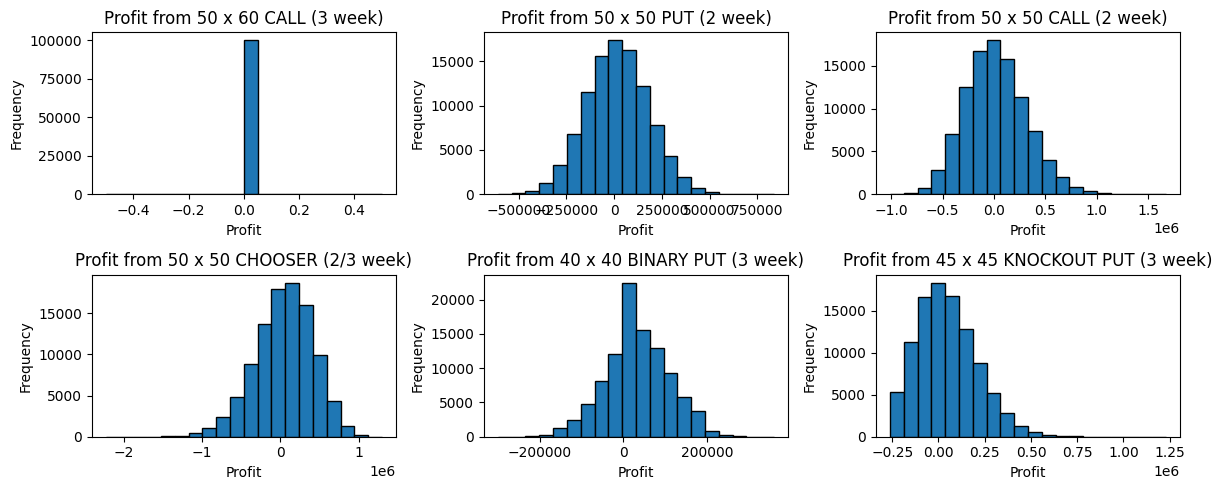

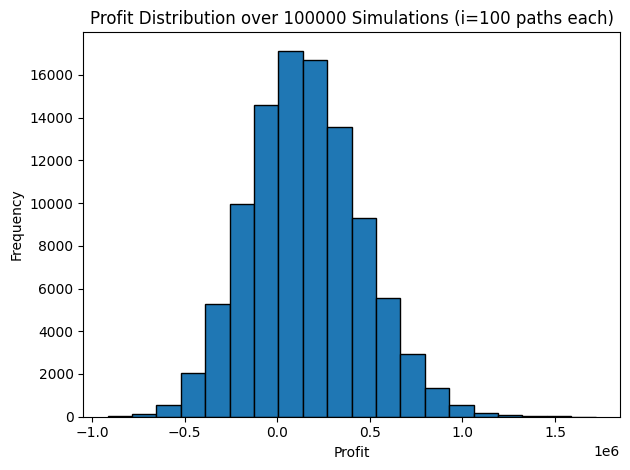

Mean Profit: 152907.0618
Median Profit: 140419.6443
5th Percentile Profit: -321028.9439
1st Percentile Profit: -489716.7639
Worst Profit: -915668.2712
Best Profit: 1719220.7172
Win Rate: 68.2180%


In [78]:
## Simulation

def simulate_manual(S0, sigma, T, N, i, display=False):

    ## Simulation
    paths = simulate_gbm(S0, sigma, T, N, i)
    three_week_prices = paths[:, 59]
    two_week_prices = paths[:, 39]

    fifty_put_three = 0
    fifty_call_three = 0
    thirtyfive_put_three = 0
    forty_put_three = 0
    fourtyfive_put_three = 0
    sixty_call_three = 0
    fifty_put_two = 0
    fifty_call_two = 0
    fourty_binary_put_three = 0

    for item in three_week_prices:
        fifty_put_three += max(50 - item, 0) / i
        fifty_call_three += max(item - 50, 0) / i
        thirtyfive_put_three += max(35 - item, 0) / i
        forty_put_three += max(40 - item, 0) / i
        fourtyfive_put_three += max(45 - item, 0) / i
        sixty_call_three += max(item - 60, 0) / i
        fourty_binary_put_three += 10 / i if item < 40 else 0

    for item in two_week_prices:
        fifty_put_two += max(50 - item, 0) / i
        fifty_call_two += max(item - 50, 0) / i

    fifty_chooser_two_three = 0
    choices = np.array([1 if item > 50 else -1 for item in two_week_prices])

    for num, item in enumerate(three_week_prices):
        if choices[num] == 1:
            fifty_chooser_two_three += max(item - 50, 0) / i
        else:
            fifty_chooser_two_three += max(50 - item, 0) / i

    row_mins = paths.min(axis=1)
    fourtyfive_knockout_put = 0
    selected = np.array([1 if item >= 35 else -1 for item in row_mins])
    for num, item in enumerate(three_week_prices):
        if selected[num] == 1:
            fourtyfive_knockout_put += max(45 - item, 0) / i
        else:
            fourtyfive_knockout_put += 0

    ## PROFITABLE STRATEGIES ##
    # Sell 50 x 60 CALL (3 week) - REJECTED
    sell_price = 8.8
    profit_one = 50 * (sell_price - sixty_call_three) * 3000
    profit_one = 0
    
    # Buy 50 x 50 PUT (2 week)
    buy_price = 9.75
    profit_two = 50 * (fifty_put_two - buy_price) * 3000
    
    # Buy 50 x 50 CALL (2 week)
    buy_price = 9.75
    profit_three = 50 * (fifty_call_two - buy_price) * 3000
    
    # Sell 50 x 50 CHOOSER (2/3 week)
    sell_price = 22.2
    profit_four = 50 * (sell_price - fifty_chooser_two_three) * 3000
    
    # Sell 50 x 40 BINARY PUT (3 week)
    sell_price = 5
    profit_five = 50 * (sell_price - fourty_binary_put_three) * 3000
    
    # Buy 500 x 45 KNOCKOUT PUT (3 week)
    buy_price = 0.175
    profit_six = 500 * (fourtyfive_knockout_put - buy_price) * 3000

    ## RISK-AVERSE ADDITIONS
    # Buy 50 x 50 PUT (3 week)
    buy_price = 12.05
    profit_seven = 50 * (fifty_put_three - buy_price) * 3000

    # Buy 50 x 50 CALL (3 week)
    buy_price = 12.05
    profit_eight = 50 * (fifty_call_three - buy_price) * 3000

    # Sell 50 x 35 PUT (3 week)
    sell_price = 4.33
    profit_nine = 50 * (sell_price - thirtyfive_put_three) * 3000

    # Buy 50 x 45 PUT (3 week)
    buy_price = 9.1
    profit_ten = 50 * (fourtyfive_put_three - buy_price) * 3000

    # Total Profit
    total_profit = profit_one + profit_two + profit_three + profit_four + profit_five + profit_six + profit_seven + profit_eight + profit_nine + profit_ten

    if display:
        print(f"Profit from selling 50 x 60 CALL (3 week): {profit_one:.4f}")
        print(f"Profit from buying 50 x 50 PUT (2 week): {profit_two:.4f}")
        print(f"Profit from buying 50 x 50 CALL (2 week): {profit_three:.4f}")
        print(f"Profit from selling 50 x 50 CHOOSER (2/3 week): {profit_four:.4f}")
        print(f"Profit from selling 50 x 40 BINARY PUT (3 week): {profit_five:.4f}")
        print(f"Profit from buying 500 x 45 KNOCKOUT PUT (3 week): {profit_six:.4f}")
        print(f"Total Profit: {total_profit:.4f}")

    return total_profit, profit_one, profit_two, profit_three, profit_four, profit_five, profit_six



S0 = 50         # initial price
sigma = 2.51    # annualized volatility (251%)
T = 15/252      # 15 trading days total
N = 15 * 4      # 60 steps total
i = 100     # number of paths in IMC Simulation
k = 100000     # number of IMC Simulations to run

profits = []
sixty_call = []
fifty_put_two = []
fifty_call_two = []
fifty_chooser = []
fourty_binary_put = []
fourtyfive_knockout_put = []
for _ in range(k):
    profit, one, two, three, four, five, six = simulate_manual(S0, sigma, T, N, i)
    profits.append(profit)
    sixty_call.append(one)
    fifty_put_two.append(two)
    fifty_call_two.append(three)
    fifty_chooser.append(four)
    fourty_binary_put.append(five)
    fourtyfive_knockout_put.append(six)
    if _ % (k/10) == 0:
        print(f"Completed {_} simulations...")

plt.figure(figsize=(12, 5))
plt.subplot(2, 3, 1)
plt.hist(sixty_call, bins=20, edgecolor='black')
plt.title('Profit from 50 x 60 CALL (3 week)')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.subplot(2, 3, 2)
plt.hist(fifty_put_two, bins=20, edgecolor='black')
plt.title('Profit from 50 x 50 PUT (2 week)')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.subplot(2, 3, 3)
plt.hist(fifty_call_two, bins=20, edgecolor='black')
plt.title('Profit from 50 x 50 CALL (2 week)')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.subplot(2, 3, 4) 
plt.hist(fifty_chooser, bins=20, edgecolor='black')
plt.title('Profit from 50 x 50 CHOOSER (2/3 week)')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.subplot(2, 3, 5)
plt.hist(fourty_binary_put, bins=20, edgecolor='black')
plt.title('Profit from 40 x 40 BINARY PUT (3 week)')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.subplot(2, 3, 6)   
plt.hist(fourtyfive_knockout_put, bins=20, edgecolor='black')
plt.title('Profit from 45 x 45 KNOCKOUT PUT (3 week)')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.hist(profits, bins=20, edgecolor='black')
plt.title(f'Profit Distribution over {k} Simulations (i={i} paths each)')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

mean = np.mean(profits)
median = np.median(profits)
p05 = np.percentile(profits, 5)
p01 = np.percentile(profits, 1)
worst = np.min(profits)
best = np.max(profits)
winrate = np.mean(np.array(profits) > 0)

print(f"Mean Profit: {mean:.4f}")
print(f"Median Profit: {median:.4f}")
print(f"5th Percentile Profit: {p05:.4f}")
print(f"1st Percentile Profit: {p01:.4f}")
print(f"Worst Profit: {worst:.4f}")
print(f"Best Profit: {best:.4f}")
print(f"Win Rate: {winrate:.4%}")